# Model selection 

In [ ]:
from sklearn.model_selection import train_test_split , cross_val_predict
import seaborn as sns
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, AdaBoostRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
import xgboost
import sklearn.metrics as metrics 
import math
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

I am starting with 2 data sets after the first models check I will choose the best dataset to continue forward

In [371]:
x = pd.read_pickle('tv_model')
x_ = pd.read_pickle('tv_model_')
tv_ = pd.read_pickle('tv_show_3.pkl')

In [372]:
x.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 163047 entries, 0 to 163046
Data columns (total 18 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   id                       163047 non-null  int64  
 1   name                     163047 non-null  int64  
 2   number_of_seasons        163047 non-null  int64  
 3   number_of_episodes       163047 non-null  int64  
 4   original_language        163047 non-null  int64  
 5   vote_count               163047 non-null  int64  
 6   vote_average             163047 non-null  float64
 7   type                     163047 non-null  int64  
 8   genres                   163047 non-null  int64  
 9   spoken_languages         163047 non-null  int64  
 10  production_countries     163047 non-null  int64  
 11  year_start               163047 non-null  float64
 12  month_end                163047 non-null  float64
 13  polarity                 163047 non-null  int64  
 14  over

In [373]:
tv_.info()

<class 'pandas.core.frame.DataFrame'>
Index: 163047 entries, 0 to 168638
Data columns (total 26 columns):
 #   Column                Non-Null Count   Dtype   
---  ------                --------------   -----   
 0   id                    163047 non-null  int64   
 1   name                  163042 non-null  category
 2   number_of_seasons     163047 non-null  int64   
 3   number_of_episodes    163047 non-null  int64   
 4   original_language     163047 non-null  category
 5   vote_count            163047 non-null  int64   
 6   vote_average          163047 non-null  float64 
 7   overview              89749 non-null   string  
 8   adult                 163047 non-null  bool    
 9   in_production         163047 non-null  bool    
 10  original_name         163042 non-null  category
 11  popularity            163047 non-null  float64 
 12  type                  163047 non-null  category
 13  status                163047 non-null  category
 14  genres                96265 non-null   ca

In [375]:

y = tv_['popularity']
#x =x.drop('name',axis=1)
#x_ =x_.drop('name',axis=1)

#y_ = tv_['popularity']

# split the data to Train test valid 

In [376]:
x_train,x_temp,y_train,y_temp = train_test_split(x,y,test_size=0.3,random_state=42)

x_test,x_valid,y_test,y_valid = train_test_split(x_temp,y_temp,test_size=0.5,random_state=42)
############# No nan fill data ######################
_x_train,_x_temp,_y_train,_y_temp = train_test_split(x_,y,test_size=0.3,random_state=42)

_x_test,_x_valid,_y_test,_y_valid = train_test_split(_x_temp,_y_temp,test_size=0.5,random_state=42)

# Metrics to evaluate the best model 

In [377]:
def regressionMetrics(y, yhat):
    res = {
        'MSE': metrics.mean_squared_error(y, yhat),
        'RMSE': np.sqrt(metrics.mean_squared_error(y, yhat)),
        'MAE': metrics.mean_absolute_error(y, yhat),
        'R2': metrics.r2_score(y, yhat)
    }

    # Check if all values are > -1 to safely apply log
    if np.all(y > -1) and np.all(yhat > -1):
        rmsle = np.sqrt(metrics.mean_squared_log_error(y, yhat))
        res['RMSLE'] = rmsle
    else:
        res['RMSLE'] = 'Not applicable (values ≤ -1)'

    return res

# The chosen models :
linear reggression ,SVR, randomforrest, xgboost, adaboost, grdient boost

I will try each model and see who has the best resualts (judging by the metrics), after a model will be chosen I will 
use fine tuning to optemize the model

In [310]:
models_lst = pd.DataFrame()

models_lst_ = pd.DataFrame()

## Linear Regression
Using cross validation for rebustness

In [381]:
from sklearn.model_selection import cross_val_predict

# Predict using cross-validation
model1 = LinearRegression()
pred1 = cross_val_predict(model1, x_train, y_train, cv=5)
pred1 = np.maximum(pred1,0)# to avoid negative values
# Compute all regression metrics using your custom function
regressionMetrics(y_train, pred1)


{'MSE': 1497.9130286288803,
 'RMSE': np.float64(38.70288139956611),
 'MAE': 6.024728976575231,
 'R2': 0.14471870059733294,
 'RMSLE': np.float64(0.9149221535494433)}

In [382]:
#Entering each model to a DF for evaluation at the end
model_dict = {'model': "Linear Regression"}
new_row = pd.DataFrame([{**model_dict, **regressionMetrics(y_train,pred1)}])
models_lst = pd.concat([models_lst, new_row], ignore_index=True)
models_lst

,model,MSE,RMSE,MAE,R2,RMSLE
0,Linear Regression,1497.913029,38.702881,6.024729,0.144719,0.914922


<Axes: xlabel='popularity'>

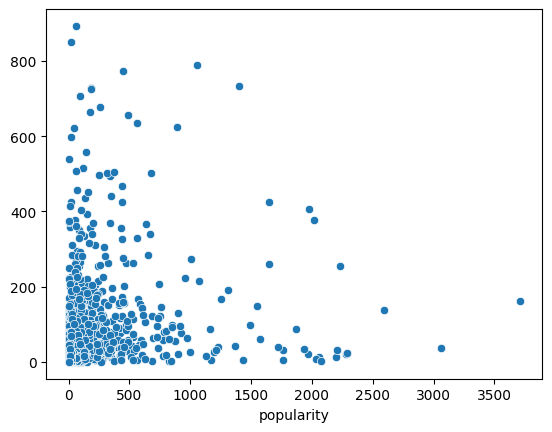

In [383]:
sns.scatterplot(x=y_train , y= pred1)


In [ ]:
# Predict using cross-validation on the not cleaned dataset 
model1_ = LinearRegression()
pred1_ = cross_val_predict(model1_, _x_train, _y_train, cv=5)
pred1_ = np.maximum(pred1_,0)
# Compute all regression metrics using your custom function
regressionMetrics(_y_train, pred1_)


{'MSE': 1503.8343890765934,
 'RMSE': np.float64(38.77930361773653),
 'MAE': 5.929112977449321,
 'R2': 0.14133771067257928,
 'RMSLE': np.float64(0.8954216699596403)}

<Axes: xlabel='popularity'>

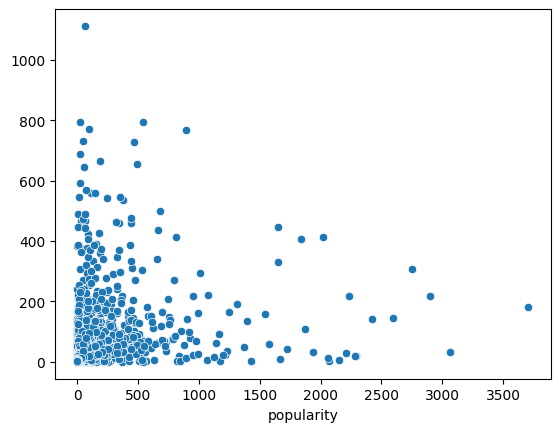

In [120]:
sns.scatterplot(x=_y_train , y= pred1_)

In [250]:
model_dict = {'model_': "Linear Regression"}
new_row = pd.DataFrame([{**model_dict, **regressionMetrics(_y_train,pred1_)}])
models_lst_ = pd.concat([models_lst_, new_row], ignore_index=True)
models_lst_

,model_,MSE,RMSE,MAE,R2,RMSLE
0,Linear Regression,1578.402684,39.729116,6.228625,0.138605,0.929165


The linear reggression dosent looks like a good model 

# SVR

In [58]:
model2 = SVR()
model2.fit(x_train,y_train)
pred2 = model2.predict(x_valid)
regressionMetrics(y_valid,pred2)

{'MSE': 1996.9516510094086,
 'RMSE': np.float64(44.68726497571102),
 'MAE': 5.4063291020793205,
 'RMSLE': np.float64(0.9032310708360436)}

SVR is very heavy consume a lot of computer time & power I diceded to drop this model

In [63]:
from sklearn.model_selection import cross_val_score
from sklearn.metrics import make_scorer, mean_squared_error
# Initialize your model
model2 = SVR()

# Cross-validation (e.g. 5-fold)
scores = cross_val_score(model2, _x_train, _y_train, 
                         cv=5, 
                         scoring='neg_root_mean_squared_error')

# Since sklearn returns NEGATIVE RMSE, take the positive:
rmse_scores = -scores

KeyboardInterrupt: 

In [59]:
model_dict = {'model': "SVR"}
new_row = pd.DataFrame([{**model_dict, **regressionMetrics(y_valid,pred2)}])
models_lst = pd.concat([models_lst, new_row], ignore_index=True)
models_lst

,model,MSE,RMSE,MAE,RMSLE
0,Linear Regression,1380.756973,37.158538,6.517895,0.992144
1,SVR,1996.951651,44.687265,5.406329,0.903231


<Axes: xlabel='popularity'>

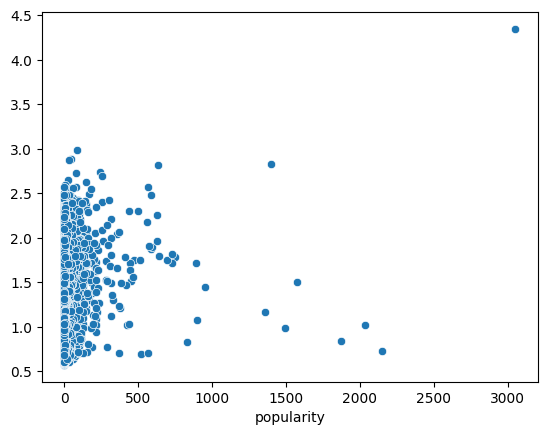

In [60]:
sns.scatterplot(x=y_valid, y=pred2)

In [61]:
model2_ = SVR()
model2_.fit(_x_train,_y_train)
pred2_ = model2_.predict(_x_valid)
regressionMetrics(_y_valid,pred2_)

{'MSE': 1993.7141549736446,
 'RMSE': np.float64(44.65102635968903),
 'MAE': 5.329292369404957,
 'RMSLE': np.float64(0.8540859452591878)}

In [ ]:
model_dict = {'model': "SVR"}
new_row = pd.DataFrame([{**model_dict, **regressionMetrics(_y_valid,pred2_)}])
models_lst_ = pd.concat([models_lst_, new_row], ignore_index=True)
models_lst_

# Random forrest

In [379]:
model3 = RandomForestRegressor(n_jobs =-1)
pred3 = cross_val_predict(model3,x_train,y_train,cv=5)
regressionMetrics(y_train,pred3)

{'MSE': 1196.8872653154494,
 'RMSE': np.float64(34.596058522835364),
 'MAE': 4.314880988849621,
 'R2': 0.3165989774089041,
 'RMSLE': np.float64(0.5064759717535142)}

# Compare to the not cleaned data

In [380]:
model3_ = RandomForestRegressor(n_jobs =-1)
pred3_ = cross_val_predict(model3_,_x_train,_y_train,cv=5)
regressionMetrics(_y_train,pred3_)

{'MSE': 1202.8750302030815,
 'RMSE': np.float64(34.68248881212364),
 'MAE': 4.323255087314603,
 'R2': 0.3131800717476727,
 'RMSLE': np.float64(0.5087618581517019)}

<Axes: xlabel='popularity'>

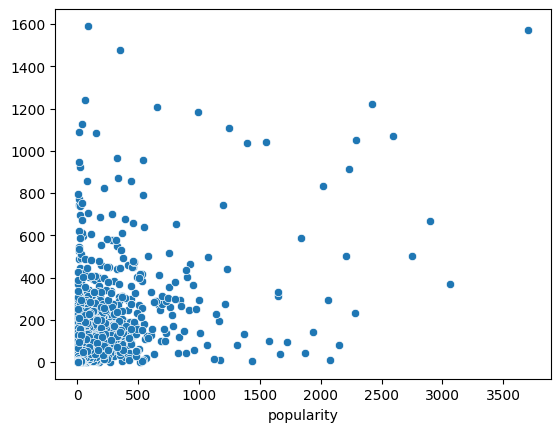

In [223]:
sns.scatterplot(x=_y_train, y=pred3_)

In [384]:
#cleaned data
model_dict = {'model': "RandomForest"}
new_row = pd.DataFrame([{**model_dict, **regressionMetrics(y_train,pred3)}])
models_lst = pd.concat([models_lst, new_row], ignore_index=True)
models_lst

,model,MSE,RMSE,MAE,R2,RMSLE
0,Linear Regression,1497.913029,38.702881,6.024729,0.144719,0.914922
1,RandomForest,1196.887265,34.596059,4.314881,0.316599,0.506476


In [251]:
model_dict = {'model_': "RandomForest"}
new_row = pd.DataFrame([{**model_dict, **regressionMetrics(_y_train,pred3_)}])
models_lst_ = pd.concat([models_lst_, new_row], ignore_index=True)
models_lst_

,model_,MSE,RMSE,MAE,R2,RMSLE
0,Linear Regression,1578.402684,39.729116,6.228625,0.138605,0.929165
1,RandomForest,1211.639543,34.808613,4.520936,0.338762,0.524756


<Axes: xlabel='popularity'>

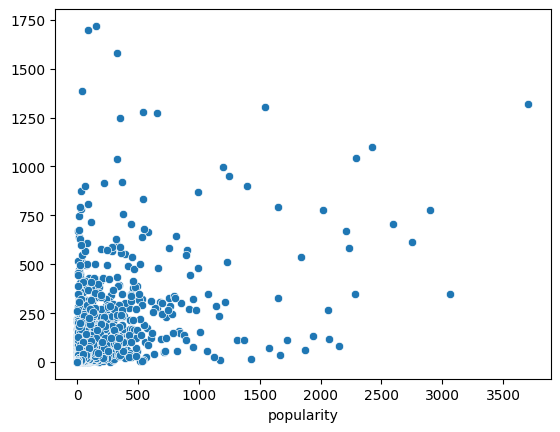

In [252]:
sns.scatterplot(x=y_train, y=pred3)

# ADABoost
Very poor performance

In [385]:
model4 = AdaBoostRegressor(random_state=1)
pred4 = cross_val_predict(model4,x_train,y_train,cv=5)
regressionMetrics(y_train,pred4)

{'MSE': 12622.579498076697,
 'RMSE': np.float64(112.3502536627163),
 'MAE': 78.35252220119432,
 'R2': -6.207265033812093,
 'RMSLE': np.float64(3.173660184706575)}

In [ ]:
model4_ = AdaBoostRegressor(random_state=1)
pred4_ = cross_val_predict(model4_,_x_train,_y_train,cv=5)
regressionMetrics(_y_train,pred4_)

In [386]:
model_dict = {'model': "ADABoost"}
new_row = pd.DataFrame([{**model_dict, **regressionMetrics(y_train,pred4)}])
models_lst = pd.concat([models_lst, new_row], ignore_index=True)
models_lst

,model,MSE,RMSE,MAE,R2,RMSLE
0,Linear Regression,1497.913029,38.702881,6.024729,0.144719,0.914922
1,RandomForest,1196.887265,34.596059,4.314881,0.316599,0.506476
2,ADABoost,12622.579498,112.350254,78.352522,-6.207265,3.173660


In [ ]:
sns.scatterplot(x=y_valid, y=pred4)

# GBM

In [387]:
model5 = GradientBoostingRegressor(random_state=42)
pred5 = cross_val_predict(model5,x_train,y_train,cv=5)
pred5 = np.maximum(pred5,0)
regressionMetrics(y_train,pred5)

{'MSE': 1289.0038462581742,
 'RMSE': np.float64(35.902699707099664),
 'MAE': 4.6805995315933115,
 'R2': 0.2640020725556623,
 'RMSLE': np.float64(0.6305192552456643)}

In [139]:
model5_ = GradientBoostingRegressor(random_state=42)
pred5_ = cross_val_predict(model5_,_x_train,_y_train,cv=5)
pred5 = np.maximum(pred5_,0)
regressionMetrics(_y_train,pred5_)

{'MSE': 1370.3533012400942,
 'RMSE': np.float64(37.01828333729286),
 'MAE': 4.835460501309785,
 'RMSLE': 'Not applicable (values ≤ -1)'}

It wasn't an easy descision this is where I decided to continue with the cleaned dataset

In [388]:
model_dict = {'model': "GBM"}
new_row = pd.DataFrame([{**model_dict, **regressionMetrics(y_train,pred5)}])
models_lst = pd.concat([models_lst, new_row], ignore_index=True)
models_lst

,model,MSE,RMSE,MAE,R2,RMSLE
0,Linear Regression,1497.913029,38.702881,6.024729,0.144719,0.914922
1,RandomForest,1196.887265,34.596059,4.314881,0.316599,0.506476
2,ADABoost,12622.579498,112.350254,78.352522,-6.207265,3.173660
3,GBM,1289.003846,35.902700,4.680600,0.264002,0.630519


In [140]:
#For the non cleaned DB:
model_dict = {'model_': "GBM"}
new_row = pd.DataFrame([{**model_dict, **regressionMetrics(_y_train,pred5_)}])
models_lst_ = pd.concat([models_lst_, new_row], ignore_index=True)
models_lst_

,model_,MSE,RMSE,MAE,RMSLE
0,RandomForest,1298.812190,36.039037,4.559779,0.527635
1,GBM,1370.353301,37.018283,4.835461,Not applicable (values ≤ -1)


Seems like the cleaned DB is better, Therfore from know on I will continue with the cleaned model

<Axes: xlabel='popularity'>

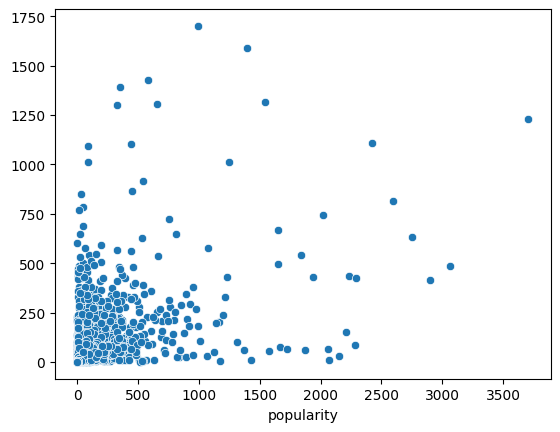

In [130]:
sns.scatterplot(x=y_train, y=pred5)

# XGBoost

In [ ]:
model6 = xgboost.XGBRegressor(n_jobs = -1,learning_rate=0.1)
pred6 = cross_val_predict(model6,x_train,y_train,cv=5)
pred6 = np.maximum(pred6,0) # If there is negative prediction make it 0

regressionMetrics(y_train,pred6)

{'MSE': 1196.911378644297,
 'RMSE': np.float64(34.596407019288826),
 'MAE': 4.285153309684958,
 'R2': 0.3165852091334199,
 'RMSLE': np.float64(0.5315268866832946)}

In [391]:
#None clean data
model6_ = xgboost.XGBRegressor(n_jobs = -1,learning_rate=0.1)
pred6_= cross_val_predict(model6_,_x_train,_y_train,cv=5)
pred6_ = np.maximum(pred6_,0)

regressionMetrics(_y_train,pred6_)

{'MSE': 1193.4906617401568,
 'RMSE': np.float64(34.54693418727857),
 'MAE': 4.303679589208816,
 'R2': 0.3185383767357737,
 'RMSLE': np.float64(0.5334732996765627)}

In [390]:
model_dict = {'model': "XGBoost"}
new_row = pd.DataFrame([{**model_dict, **regressionMetrics(y_train,pred6)}])
models_lst = pd.concat([models_lst, new_row], ignore_index=True)
models_lst

,model,MSE,RMSE,MAE,R2,RMSLE
0,Linear Regression,1497.913029,38.702881,6.024729,0.144719,0.914922
1,RandomForest,1196.887265,34.596059,4.314881,0.316599,0.506476
2,ADABoost,12622.579498,112.350254,78.352522,-6.207265,3.173660
3,GBM,1289.003846,35.902700,4.680600,0.264002,0.630519
4,XGBoost,1196.911379,34.596407,4.285153,0.316585,0.531527


<Axes: xlabel='popularity'>

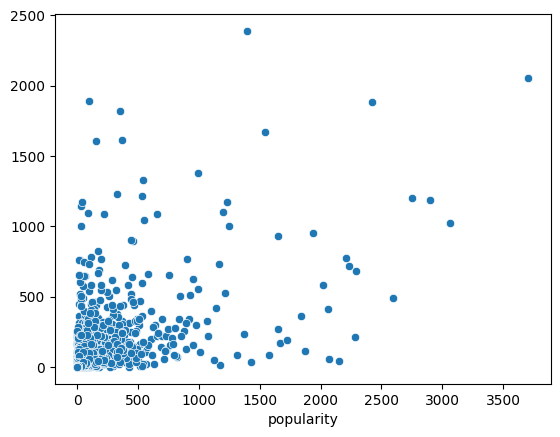

In [260]:
sns.scatterplot(x=y_train, y=pred6)

# Getting the average prediction of the top 2 models:

In [392]:
pred_metrix= np.array([pred3,pred6])
average_pred = np.mean(pred_metrix, axis=0)
regressionMetrics(y_train,average_pred)


{'MSE': 1155.5773275178615,
 'RMSE': np.float64(33.99378365992614),
 'MAE': 4.203801433970045,
 'R2': 0.34018620617485273,
 'RMSLE': np.float64(0.5051792625600688)}

# I avreged the top 2 best prediction to see if I can yield better resault.

In [393]:
model_dict = {'model': "average_top2_models"}
new_row = pd.DataFrame([{**model_dict, **regressionMetrics(y_train,average_pred)}])
models_lst = pd.concat([models_lst, new_row], ignore_index=True)
models_lst

,model,MSE,RMSE,MAE,R2,RMSLE
0,Linear Regression,1497.913029,38.702881,6.024729,0.144719,0.914922
1,RandomForest,1196.887265,34.596059,4.314881,0.316599,0.506476
2,ADABoost,12622.579498,112.350254,78.352522,-6.207265,3.173660
3,GBM,1289.003846,35.902700,4.680600,0.264002,0.630519
4,XGBoost,1196.911379,34.596407,4.285153,0.316585,0.531527
5,average_top2_models,1155.577328,33.993784,4.203801,0.340186,0.505179


In [153]:
pred_met =np.array([pred3,pred6])
avrage_2 = np.mean(pred_met,axis=0)
regressionMetrics(y_train,avrage_2)

{'MSE': 1217.0057201996276,
 'RMSE': np.float64(34.885609070211565),
 'MAE': 4.51060333202861,
 'RMSLE': np.float64(0.5487900975351682)}

<Axes: xlabel='popularity'>

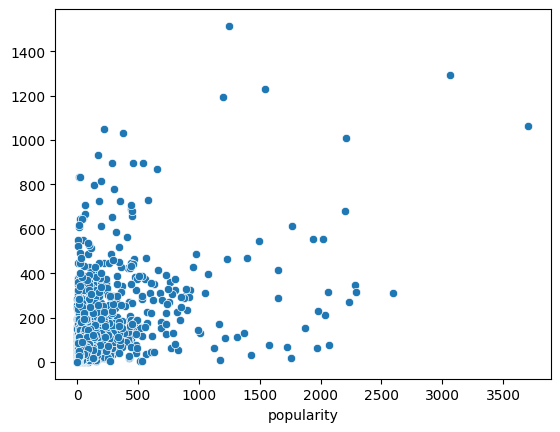

In [394]:
sns.scatterplot(x = y_train,y = average_pred)


<Axes: xlabel='popularity'>

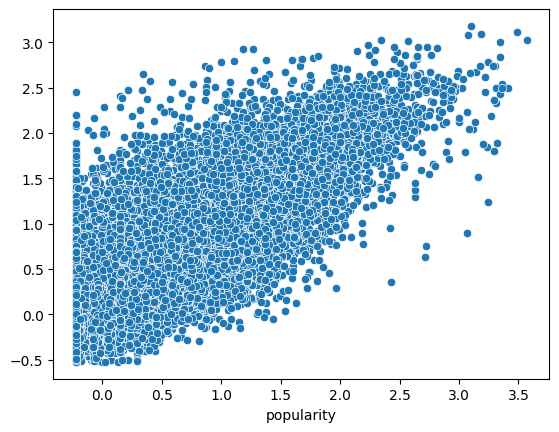

In [395]:
sns.scatterplot(x = np.log10(y_train),y = np.log10(average_pred))

# Fine tuning
The chosen models are Random forrest, GBM, XGBoost - the average of the 3 yields the best resaults

In [155]:
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import make_scorer, mean_squared_log_error

## Creat RMSLE as a metric for gridsearch

In [275]:
#rmsle_scorer = make_scorer(lambda y_true, y_pred: np.sqrt(mean_squared_log_error(y_true, y_pred)), greater_is_better=False)
safe_rmsle = lambda y_true, y_pred: np.sqrt(mean_squared_log_error(
    np.maximum(0, y_true), np.maximum(0, y_pred)
))

rmsle_scorer = make_scorer(safe_rmsle, greater_is_better=False)


In [162]:
param_grid ={
    'n_estimators': [ 80, 100,150],  # Number of trees in the forest
    'max_features': [ None,'sqrt', 'log2'],  # Number of features to consider at every split
    'max_depth': [None, 20, 30, 40, 50],  # Maximum number of levels in tree
    'min_samples_split': [2, 5, 8],  # Minimum number of samples required to split a node
    'min_samples_leaf': [2, 4, 8],  # Minimum number of samples required at each leaf node
}

In [163]:
rf =RandomForestRegressor()
grid_search = GridSearchCV(estimator= rf,param_grid=param_grid,cv=3,n_jobs=-1,verbose=2,scoring=rmsle_scorer,error_score='raise')
grid_search.fit(x_train,y_train)
print("Best Parameters:", grid_search.best_params_)
print("Best Score:", -grid_search.best_score_)

Fitting 3 folds for each of 405 candidates, totalling 1215 fits
Best Parameters: {'max_depth': 30, 'max_features': None, 'min_samples_leaf': 4, 'min_samples_split': 8, 'n_estimators': 80}
Best Score: 0.5328519887394321


In [166]:
param_df = pd.DataFrame()


In [167]:
model_dict = {'model': 'RandomForest'} 
new_row = pd.DataFrame([{**model_dict, **grid_search.best_params_}])
param_df = pd.concat([param_df,new_row], ignore_index=True)
param_df

,model,max_depth,max_features,min_samples_leaf,min_samples_split,n_estimators
0,RandomForest,30,None,4,8,80


In [396]:
model3_GS = RandomForestRegressor(n_jobs =-1,**grid_search.best_params_)
pred3 = cross_val_predict(model3_GS,x_train,y_train,cv=5)
regressionMetrics(y_train,pred3)


{'MSE': 1184.58585004458,
 'RMSE': np.float64(34.417812975907985),
 'MAE': 4.140039637133173,
 'R2': 0.3236228634665558,
 'RMSLE': np.float64(0.49293046750978414)}

In [397]:
#model3_GS_ = RandomForestRegressor(n_jobs =-1,**grid_search.best_params_)
#pred3_ = cross_val_predict(model3_GS_,_x_train,_y_train,cv=5)
#regressionMetrics(_y_train,pred3_) 

# XGBoost fine tuning

In [273]:
xgb_model = xgboost.XGBRegressor(objective='reg:squarederror', random_state=42)

param_grid_ = {
    'n_estimators': [100, 150],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}


In [282]:
grid_search_xg = GridSearchCV(
    estimator=xgb_model,
    param_grid=param_grid_,
    cv=5,  # 5-fold cross-validation
    scoring= 'r2',  # or 'r2', 'accuracy', etc.
    n_jobs=-1,
    verbose=1
)


In [283]:
grid_search_xg.fit(x_train, y_train)


Fitting 5 folds for each of 72 candidates, totalling 360 fits


GridSearchCV(cv=5,
             estimator=XGBRegressor(base_score=None, booster=None,
                                    callbacks=None, colsample_bylevel=None,
                                    colsample_bynode=None,
                                    colsample_bytree=None, device=None,
                                    early_stopping_rounds=None,
                                    enable_categorical=False, eval_metric=None,
                                    feature_types=None, feature_weights=None,
                                    gamma=None, grow_policy=None,
                                    importance_type=None,
                                    interaction_constraints=None...
                                    max_cat_to_onehot=None, max_delta_step=None,
                                    max_depth=None, max_leaves=None,
                                    min_child_weight=None, missing=nan,
                                    monotone_constraints=None,
                                    multi_strategy=None, n_estimators=None,
                                    n_jobs=None, num_parallel_tree=None, ...),
             n_jobs=-1,
             param_grid={'colsample_bytree': [0.8, 1.0],
                         'learning_rate': [0.01, 0.1, 0.2],
                         'max_depth': [3, 5, 7], 'n_estimators': [100, 150],
                         'subsample': [0.8, 1.0]},
             scoring='r2', verbose=1)

In [284]:
print("Best parameters:", grid_search_xg.best_params_)
print("Best score:", grid_search_xg.best_score_)

best_model = grid_search.best_estimator_

Best parameters: {'colsample_bytree': 0.8, 'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 150, 'subsample': 1.0}
Best score: 0.38914378171062947


In [398]:
model6_gs = xgboost.XGBRegressor(n_jobs = -1,**grid_search_xg.best_params_)
pred6 = cross_val_predict(model6_gs,x_train,y_train,cv=5)
pred6 = np.maximum(pred6,0)

regressionMetrics(y_train,pred6)

{'MSE': 1138.998586800439,
 'RMSE': np.float64(33.749053124501714),
 'MAE': 4.334314575379246,
 'R2': 0.34965236784929676,
 'RMSLE': np.float64(0.5578666996865765)}

In [399]:
pred_met =np.array([pred3,pred6])
avrage_2 = np.mean(pred_met,axis=0)
regressionMetrics(y_train,avrage_2)

{'MSE': 1127.6042651284972,
 'RMSE': np.float64(33.57981931351771),
 'MAE': 4.135226911975482,
 'R2': 0.3561583198365832,
 'RMSLE': np.float64(0.5070085053300768)}